# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Mohamed Fathy Mahmoud Mohamed

ID: 43-17605

Tutorial: T-01

---

Name: Sherif Wael

ID: 43-2241

Tutorial: T-01

---


## Dataset Description

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

Each row represents a customer, and each column represents customer attributes as described below.

| Column | Description|
|-|-|
|gender|Whether the customer is a male or a female|
|SeniorCitizen| Whether the customer is a senior citizen or not (1, 0)|
|Partner|Whether the customer has a partner or not (Yes, No)|
|Dependents|Whether the customer has dependents or not (Yes, No)|
|tenure| Number of months the customer has stayed with the company|
|PhoneService|Whether the customer has a phone service or not (Yes, No)|
|MultipleLines|Whether the customer has multiple lines or not (Yes, No, No phone service*)|
|InternetService|Customer’s internet service provider (DSL, Fiber optic, No)|
|OnlineSecurity|Whether the customer has online security or not (Yes, No, No internet service**)|
|OnlineBackup|Whether the customer has online backup or not (Yes, No, No internet service)|
|DeviceProtection|Whether the customer has device protection or not (Yes, No, No internet service)|
|TechSupport|Whether the customer has tech support or not (Yes, No, No internet service)|
|StreamingTV|Whether the customer has streaming TV or not (Yes, No, No internet service) |
|StreamingMovies|Whether the customer has streaming movies or not (Yes, No, No internet service)|
|Contract|The contract term of the customer (Month-to-month, One year, Two year)|
|PaperlessBilling|Whether the customer has paperless billing or not (Yes, No)|
|PaymentMethod|The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))|
|MonthlyCharges|The amount charged to the customer monthly|
|TotalCharges|The total amount charged to the customer|
|Churn|Whether the customer churned or not (Yes or No)|

\* No phone service means the customer's plan does not include calling (could be a data-only plan)

\*\* No internet service means the customer's plan does not include internet/data and so the addon package does not apply

## Importing Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2021/main/data/telecom_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85/m,$29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,$56.95/m,$1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85/m,$108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),$42.3/m,$1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,$70.7/m,$151.65,Yes


## Data Inspection

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        6976 non-null   object
 1   gender            7032 non-null   object
 2   SeniorCitizen     7032 non-null   int64 
 3   Partner           7032 non-null   object
 4   Dependents        7032 non-null   object
 5   tenure            7032 non-null   int64 
 6   PhoneService      7032 non-null   object
 7   MultipleLines     7032 non-null   object
 8   InternetService   7032 non-null   object
 9   OnlineSecurity    7032 non-null   object
 10  OnlineBackup      7032 non-null   object
 11  DeviceProtection  7032 non-null   object
 12  TechSupport       7032 non-null   object
 13  StreamingTV       7032 non-null   object
 14  StreamingMovies   7032 non-null   object
 15  Contract          7032 non-null   object
 16  PaperlessBilling  7032 non-null   object
 17  PaymentMethod 

In [3]:
df['Churn'].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

In [4]:
df.describe(include='O')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,6976,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,6180,7032
unique,6976,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1584,5783,2
top,9761-XUJWD,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,$20.05/m,$19.65,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,61,8,5163


In [5]:
df.describe()

,SeniorCitizen,tenure
count,7032.000000,7032.000000
mean,0.162400,32.421786
std,0.368844,24.545260
min,0.000000,1.000000
25%,0.000000,9.000000
50%,0.000000,29.000000
75%,0.000000,55.000000
max,1.000000,72.000000


In [6]:
df.isna().sum()

customerID           56
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        852
Churn                 0
dtype: int64

In [7]:
categorical_col = []
for column in df.columns:
    if df[column].dtype == object and len(df[column].unique()) <= 50:
        categorical_col.append(column)
        print(f"{column} : {df[column].unique()}")
        print("====================================")

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


## Data Pre-processing

change type of senior citizen to categoical 

In [8]:
df['SeniorCitizen'] = pd.Categorical(df.SeniorCitizen)
categorical_col.append('SeniorCitizen')

Drop the customer ID column

In [9]:
df = df.drop('customerID', axis = 1)

clean the values of Monthly charges and total charges

In [10]:
print(df['MonthlyCharges'].map(lambda x: x[0]).value_counts())
print(df['MonthlyCharges'].map(lambda x: x[-2:]).value_counts())

$    7032
Name: MonthlyCharges, dtype: int64
/m    7032
Name: MonthlyCharges, dtype: int64


In [11]:
df['MonthlyCharges'] = df['MonthlyCharges'].map(lambda x: x.replace('$', ''))
df['MonthlyCharges'] = df['MonthlyCharges'].map(lambda x: float(x.replace('/m', '')))


In [12]:
print(df['TotalCharges'].dropna().map(lambda x: x[0]).value_counts())

$    6180
Name: TotalCharges, dtype: int64


In [13]:
df['TotalCharges'] = df['TotalCharges'].map(lambda x: float(x.replace('$', ''))  if not pd.isnull(x) else np.nan)

In [14]:
print(df['TotalCharges'])

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7027    1990.50
7028    7362.90
7029     346.45
7030     306.60
7031    6844.50
Name: TotalCharges, Length: 7032, dtype: float64


In [15]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,6180.000000
mean,32.421786,64.798208,2281.933932
std,24.545260,30.085974,2271.511755
min,1.000000,18.250000,18.850000
25%,9.000000,35.587500,392.612500
50%,29.000000,70.350000,1390.225000
75%,55.000000,89.862500,3785.900000
max,72.000000,118.750000,8684.800000


### Fill the missing values in the total charges using regression

The values of the total charges can be imputed using regression with the attributes monthly charges and tenture

In [16]:
train_set = df[df['TotalCharges'].isnull()==False]
test_set = df[df['TotalCharges'].isnull()==True]
x_train = train_set[['tenure','MonthlyCharges']]
y_train = train_set['TotalCharges']

x_test = test_set[['tenure','MonthlyCharges']]
y_test = test_set['TotalCharges']

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor
possion_model = PoissonRegressor()
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
possion_model.fit(x_train,y_train)
y_pred = linear_model.predict(x_test)
y_pred_Poisson = possion_model.predict(x_test)

In [18]:
y_pred_Poisson[y_pred_Poisson<= 0]

array([], dtype=float64)

In [19]:
y_pred[y_pred<= 0]

array([-1360.29476234, -1387.01776318,  -370.35255284, -1196.39369058,
       -1340.69789507,  -393.5124869 ,  -275.34092859,  -191.60467154,
        -710.42864521, -1370.98396268,  -644.90757348, -1101.7735422 ,
        -778.12900787,  -162.11411902,  -149.24562775, -1087.52127509,
        -162.11202513,  -625.11392132,  -409.5462874 ,  -469.72275896,
       -1387.01776318, -1158.38694699, -1182.14142347,  -937.27792801,
        -446.36813391,  -462.59662541,    -8.30770516, -1410.17769723,
        -370.5535255 ,  -344.61975809,  -293.15626248, -1036.25247047,
        -248.21807633, -1365.63936251,  -473.09113474,  -731.21459734,
        -145.68046709,  -270.19101942,  -469.52806796,  -311.36726002,
        -216.54823287,  -509.90879348,  -249.99960972,  -296.12478683,
        -777.73125033,  -457.64978278,  -100.75065649, -1376.32856284,
         -39.18412742,  -109.65832343,  -995.67286619,   -15.23286606,
       -1333.57176151, -1096.42894204,  -490.90646863,  -712.2101786 ,
      

In [20]:
df.TotalCharges.isna().sum()

852

In [21]:
df.TotalCharges = df.TotalCharges.fillna(pd.Series(y_pred_Poisson,index=y_test.index))

In [22]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2281.188725
std,24.545260,30.085974,2279.825664
min,1.000000,18.250000,18.850000
25%,9.000000,35.587500,441.507139
50%,29.000000,70.350000,1379.950000
75%,55.000000,89.862500,3715.550000
max,72.000000,118.750000,11299.322048


## Exploratory Data Analysis

**Q1: What are the most correlated attributes with customer churn?**

**Visualization**

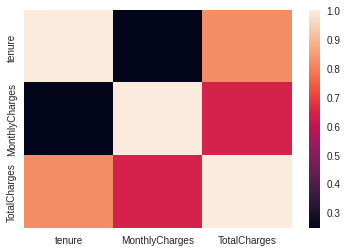

In [23]:
sns.heatmap(df.corr())

**Answer for Q1**: Your answer here

**Q2: Which payment method has the highest churn rate?**

**Visualization**

**Answer for Q2**: Your answer here

**Q3: After how many months do customers commonly churn?** (Hint: show and interpret the distribution)

**Visualization**

**Answer for Q3**: Your answer here

## Modelling

The contract type can be set to be ordinal attribute.

In [ ]:
df['Contract'] = pd.Categorical(df['Contract'],
                                      categories=['Month-to-month', 'One year', 'Two year'],
                                      ordered=True)
df['Contract']

0       Month-to-month
1             One year
2       Month-to-month
3             One year
4       Month-to-month
             ...      
7027          One year
7028          One year
7029    Month-to-month
7030    Month-to-month
7031          Two year
Name: Contract, Length: 7032, dtype: category
Categories (3, object): ['Month-to-month' < 'One year' < 'Two year']

We need to encode the churn (target)

In [ ]:
df['Churn'] = df['Churn'].astype('category').cat.codes
categorical_col.remove('Churn')
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7027    0
7028    0
7029    0
7030    1
7031    0
Name: Churn, Length: 7032, dtype: int8

Encode the categorical variables using one hot encoding

In [ ]:
categorical_features = categorical_col.copy()
ordinal_features = ['Contract']
categorical_features.remove('Contract')
print(categorical_features)
print(ordinal_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']
['Contract']


In [ ]:
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features)
df_encoded.drop(['gender_Female', 'Partner_No','Dependents_No','PhoneService_No','PaperlessBilling_No','SeniorCitizen_0'], axis='columns', inplace=True)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   tenure                                   7032 non-null   int64   
 1   Contract                                 7032 non-null   category
 2   MonthlyCharges                           7032 non-null   float64 
 3   TotalCharges                             7032 non-null   float64 
 4   Churn                                    7032 non-null   int8    
 5   gender_Male                              7032 non-null   uint8   
 6   Partner_Yes                              7032 non-null   uint8   
 7   Dependents_Yes                           7032 non-null   uint8   
 8   PhoneService_Yes                         7032 non-null   uint8   
 9   MultipleLines_No                         7032 non-null   uint8   
 10  MultipleLines_No phone service      

encode the contract using label encoding

In [ ]:
df_encoded['Contract'] = df_encoded['Contract'].astype('category').cat.codes
df_encoded['Contract']

0       0
1       1
2       0
3       1
4       0
       ..
7027    1
7028    1
7029    0
7030    0
7031    2
Name: Contract, Length: 7032, dtype: int8

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   tenure                                   7032 non-null   int64  
 1   Contract                                 7032 non-null   int8   
 2   MonthlyCharges                           7032 non-null   float64
 3   TotalCharges                             7032 non-null   float64
 4   Churn                                    7032 non-null   int8   
 5   gender_Male                              7032 non-null   uint8  
 6   Partner_Yes                              7032 non-null   uint8  
 7   Dependents_Yes                           7032 non-null   uint8  
 8   PhoneService_Yes                         7032 non-null   uint8  
 9   MultipleLines_No                         7032 non-null   uint8  
 10  MultipleLines_No phone service           7032 no

In [29]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def print_score(clf, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = clf.predict(X_train)
        clf_report = pd.DataFrame(classification_report(y_train, pred, output_dict=True))
        print("Train Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_train, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_train, pred)}\n")
        
    elif train==False:
        pred = clf.predict(X_test)
        clf_report = pd.DataFrame(classification_report(y_test, pred, output_dict=True))
        print("Test Result:")
        print("===============================================")
        print(f"Accuracy Score: {accuracy_score(y_test, pred) * 100:.2f}%")
        print("_______________________________________________")
        print(f"CLASSIFICATION REPORT:\n{clf_report}")
        print("_______________________________________________")
        print(f"Confusion Matrix: \n {confusion_matrix(y_test, pred)}\n")

In [31]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=101)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

In [32]:
print_score(tree_clf, X_train, y_train, X_test, y_test, train=True)
print_score(tree_clf, X_train, y_train, X_test, y_test, train=False)

Train Result:
Accuracy Score: 99.85%
_______________________________________________
CLASSIFICATION REPORT:
                     0            1  accuracy    macro avg  weighted avg
precision     0.997918     1.000000  0.998483     0.998959      0.998486
recall        1.000000     0.994444  0.998483     0.997222      0.998483
f1-score      0.998958     0.997214  0.998483     0.998086      0.998482
support    3834.000000  1440.000000  0.998483  5274.000000   5274.000000
_______________________________________________
Confusion Matrix: 
 [[3834    0]
 [   8 1432]]

Test Result:
Accuracy Score: 72.30%
_______________________________________________
CLASSIFICATION REPORT:
                     0           1  accuracy    macro avg  weighted avg
precision     0.824345    0.436957  0.722981     0.630651      0.729812
recall        0.805117    0.468531  0.722981     0.636824      0.722981
f1-score      0.814617    0.452193  0.722981     0.633405      0.726176
support    1329.000000  429.000000  

## Evaluation

## Decision Tree Visualization

In [33]:
feature_names = list(df_encoded.columns)
class_names = ['Churn']
print(feature_names)

['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'SeniorCitizen_1']


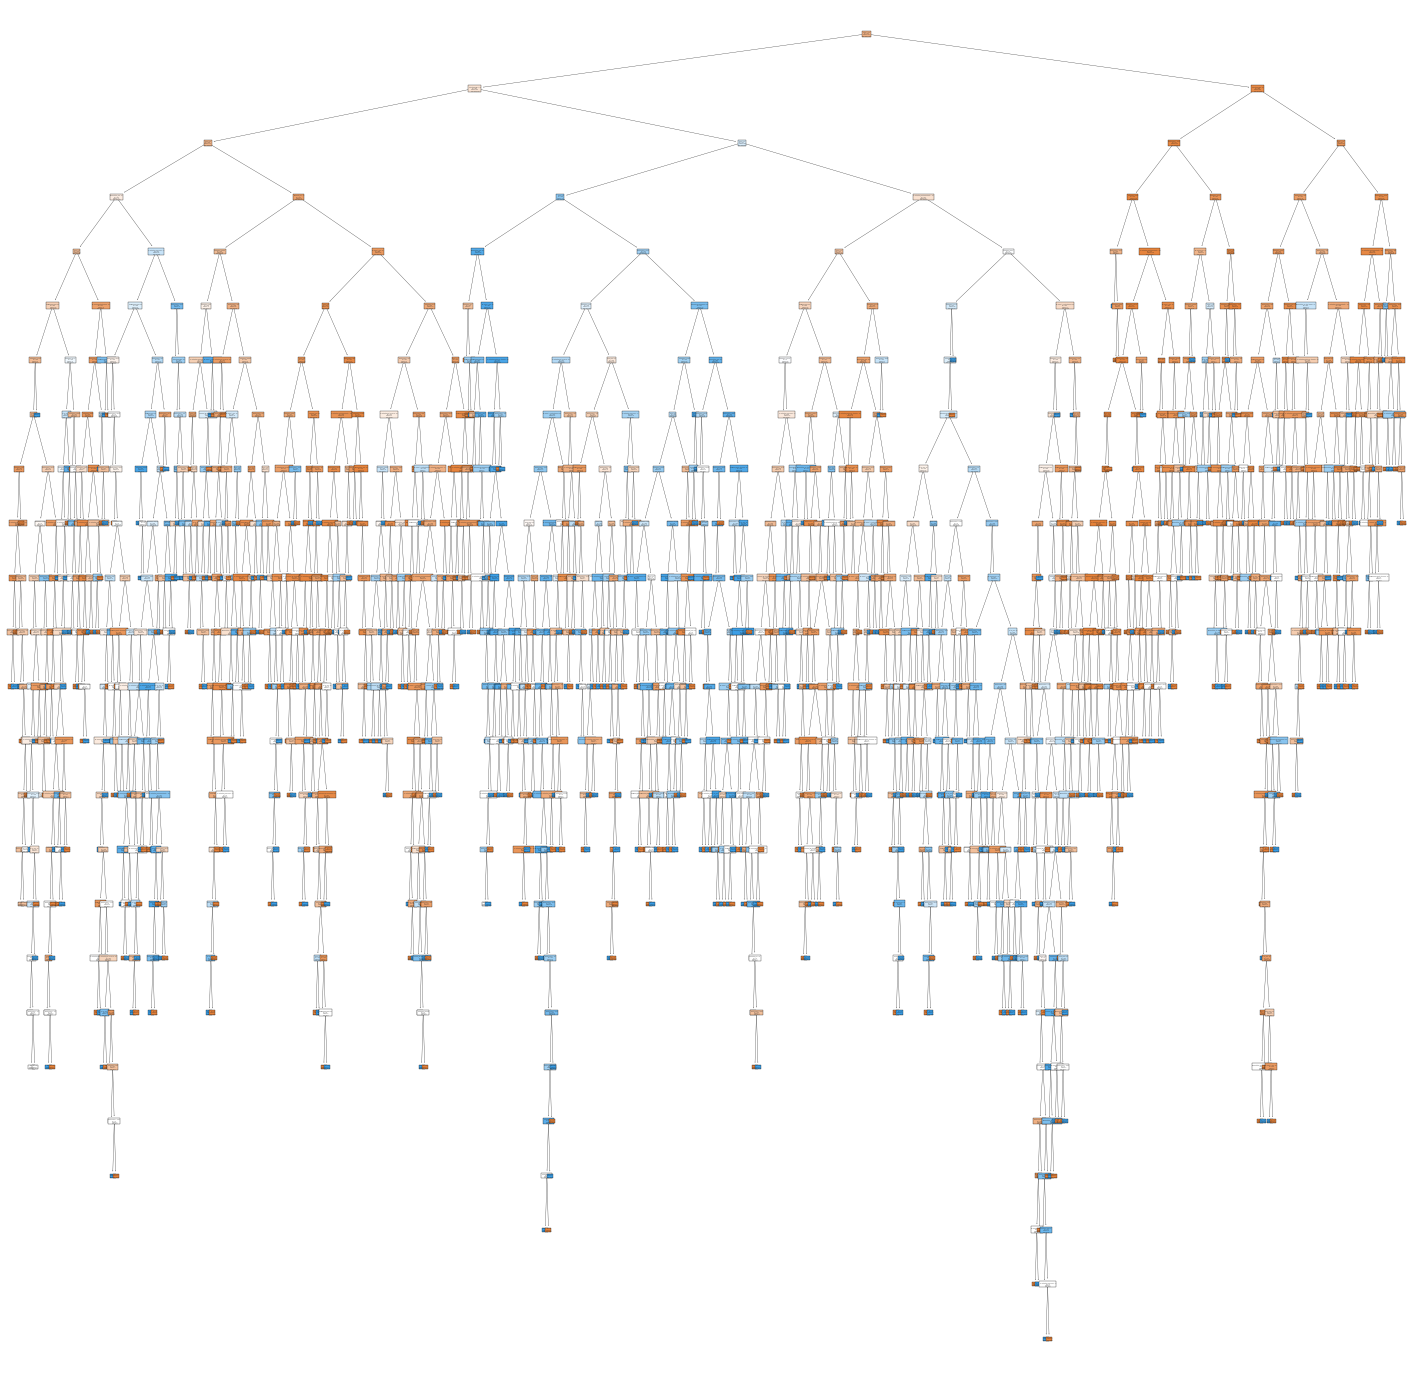

In [34]:
from sklearn import tree
fig = plt.figure(figsize=(25,25))
_ = tree.plot_tree(tree_clf,feature_names = feature_names,
                   filled=True)

## Bonus (Optional)